 **Data Import & Setup
Import CSV using Pandas
Check/convert data types
Convert date columns to datetime**


> Add blockquote



In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv("https://raw.githubusercontent.com/mrmanimk07-spec/social_media_engagement/refs/heads/main/social_media_engagement_5000.csv")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [3]:
df['posted_at']=pd.to_datetime(df['posted_at'],errors='coerce')
df['posted_at'].dtype

/tmp/ipykernel_166/630590434.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at']=pd.to_datetime(df['posted_at'],errors='coerce')


dtype('<M8[ns]')

 **Data Cleaning
 Cleaning Missing Data
Detect missing values (isnull(), isna())
Handle using: dropna(), fillna(), median/mode, forward/backward-fill
Duplicate Handling- Identify & remove duplicates**


In [6]:
df["age"].fillna(df['age'].mean(),inplace=True)
df["gender"].fillna(df["gender"].mode()[0],inplace=True)
df["likes"].fillna(df["likes"].median(),inplace=True)
df["comments"].fillna(df["comments"].median(),inplace=True)
df["shares"].fillna(df["shares"].median(),inplace=True)
df["sentiment"].fillna(df["sentiment"].mode()[0],inplace=True)

/tmp/ipykernel_166/3870010591.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df['age'].mean(),inplace=True)
/tmp/ipykernel_166/3870010591.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [7]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


**Data Formatting
Fix incorrect data types
Standardize categories (e.g., gender labels)
Correct unrealistic values in likes, comments, shares
Extract hashtag count
Clean sentiment labels**


In [10]:
df['likes'] = pd.to_numeric(df['likes'], errors='coerce')
df['comments'] = pd.to_numeric(df['comments'], errors='coerce')
df['shares'] = pd.to_numeric(df['shares'], errors='coerce')

In [11]:
df['gender'] = df['gender'].str.lower()
df['gender'] = df['gender'].replace({
    'm': 'male',
    'f': 'female'
})
df['gender'] = df['gender'].str.capitalize()

In [12]:
df['gender']

,gender
0,Female
1,Male
2,Female
3,Other
4,Other
...,...
4995,Male
4996,Other
4997,Female
4998,Female


In [13]:
def remove_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where((df[column] < lower) | (df[column] > upper), np.nan, df[column])

for col in ['likes','comments','shares']:
    remove_outliers(col)

In [14]:
df['hashtag_Count'] = df['hashtags'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
df[['hashtags','hashtag_Count']]

,hashtags,hashtag_Count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
...,...,...
4995,#travel #fun,2
4996,#foodie #reels,2
4997,#lifestyle #tech,2
4998,#reels #love #fitness,3


In [15]:
df['sentiment'] = df['sentiment'].str.lower()
df['sentiment'] = df['sentiment'].replace({
    'pos': 'positive',
    'positive': 'positive',
    'neg': 'negative',
    'negative': 'negative',
    'neu': 'neutral',
    'neutral': 'neutral'
})
df['sentiment'] = df['sentiment'].str.capitalize()
df['sentiment'].unique()

array(['Negative', 'Positive', 'Neutral'], dtype=object)

 **Data Exploration
 View dataset structure using head(), tail(), shape, and columns.
Check data types and info with info() and dtypes.
Generate summary statistics using describe().
Analyze categorical distributions using value_counts(), unique(), and nunique().
Create a correlation matrix for numeric fields.
Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).**


In [16]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_Count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1


In [17]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_Count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,Positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [18]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'Likes',
       'hashtag_Count'],
      dtype='object')

In [19]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [20]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_Count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.454021,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.686946,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [21]:
df['post_type'].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [22]:
df['likes'].nunique()

4293

In [23]:
df['country'].value_counts()

,count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
UK,493
Australia,493
Germany,490


In [24]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_Count
user_id,1.000000,-0.006680,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006680,1.000000,-0.013156,-0.036241,-0.007254,0.013907,0.005592,0.013288,-0.025029,0.008023,0.007228
post_id,0.020051,-0.013156,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036241,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007254,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013907,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005592,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013288,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.025029,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008023,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [25]:
df.groupby('country')['impression_count'].sum()

,impression_count
country,
Australia,23834767
Brazil,24793360
Canada,24984716
France,25656926
Germany,23816649
India,28067377
Japan,23418816
UAE,24610992
UK,25201861


In [26]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


**Data Wrangling
Use merge, concat, or join if combining DataFrames.
Create new fields such as engagement_score, log-transformed metrics, and hashtag count.
Perform groupby summaries by post_type, country, and sentiment.**


In [27]:
df1 = df.iloc[:2500]
df2 = df.iloc[2500:]
combined_df = pd.concat([df1, df2], axis=0)
combined_df.shape

(5000, 20)

In [28]:
df_extra = df[['post_id','country']]
merged_df = pd.merge(df, df_extra, on='post_id', how='left')
merged_df.head()

,user_id,age,gender,country_x,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_Count,country_y
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3,Brazil
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1,Brazil
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1,UK
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3,France
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1,UK


In [29]:
df_join = df.join(df_extra.set_index('post_id'), on='post_id', rsuffix='_new')
df_join.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_Count,country_new
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3,Brazil
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1,Brazil
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1,UK
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3,France
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1,UK


In [30]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df['engagement_score']

,engagement_score
0,8522.0
1,16163.0
2,6161.0
3,7482.0
4,16717.0
...,...
4995,20060.0
4996,21241.0
4997,15151.0
4998,19896.0


In [31]:
df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])

In [32]:
df['log_likes']

,log_likes
0,8.855378
1,9.371694
2,8.489411
3,8.585039
4,9.448018
...,...
4995,9.693445
4996,9.736547
4997,9.509556
4998,9.734773


In [33]:
df['log_comments']

,log_comments
0,5.872118
1,7.865955
2,5.843544
3,6.988413
4,7.914252
...,...
4995,7.607878
4996,7.913887
4997,7.311886
4998,7.162397


In [34]:
df['log_shares']

,log_shares
0,7.054450
1,7.499977
2,6.862758
3,6.956545
4,7.170888
...,...
4995,7.516433
4996,7.367709
4997,5.123964
4998,7.446585


In [35]:
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
df['hashtag_count']

,hashtag_count
0,3
1,1
2,1
3,3
4,1
...,...
4995,2
4996,2
4997,2
4998,3


In [36]:
df.groupby('post_type')[['likes','comments','shares','engagement_score']].mean()

,likes,comments,shares,engagement_score
post_type,,,,
image,10104.865277,1525.235766,1019.289495,12649.390537
reel,10037.802416,1504.187062,982.042089,12524.031567
text,10100.148193,1499.106024,1013.989558,12613.243775
video,10188.600000,1479.160000,996.834286,12664.594286


In [37]:
df.groupby('country')[['likes','comments','shares','engagement_score']].mean()

,likes,comments,shares,engagement_score
country,,,,
Australia,10294.124746,1485.803245,1029.693712,12809.621704
Brazil,9886.689484,1490.434524,1008.859127,12385.983135
Canada,10063.066277,1546.582846,996.245614,12605.894737
France,10372.876008,1478.695565,1051.812500,12903.384073
Germany,10130.458163,1531.826531,973.379592,12635.664286
India,9962.468224,1494.917757,1035.315888,12492.701869
Japan,10088.862288,1530.434322,959.351695,12578.648305
UAE,10227.487078,1541.214712,989.075547,12757.777336
UK,9935.650101,1463.042596,985.681542,12384.374239


In [38]:
df.groupby('sentiment')[['likes','comments','shares','engagement_score']].mean()

,likes,comments,shares,engagement_score
sentiment,,,,
Negative,10208.096875,1516.094792,1007.307292,12731.498958
Neutral,9923.194499,1528.404060,996.565160,12448.163720
Positive,10180.062077,1480.650617,1005.086749,12665.799443


In [39]:
df.groupby(['country','post_type','sentiment'])[['likes','comments','shares','engagement_score']].mean()

likes     comments       shares  \
country   post_type sentiment                                           
Australia image     Negative    8006.131579  1082.052632   994.578947   
                    Neutral     9683.678571  1717.047619  1156.857143   
                    Positive   10234.704545  1564.666667  1075.439394   
          reel      Negative   11415.040000  1544.200000  1061.280000   
                    Neutral    10094.719512  1312.243902   981.780488   
...                                     ...          ...          ...   
USA       text      Neutral     8831.100000  1467.740000   955.900000   
                    Positive   11199.514286  1408.014286  1070.300000   
          video     Negative   10290.450000  1398.850000  1049.650000   
                    Neutral     9592.750000  1410.475000   920.100000   
                    Positive    9581.625000  1530.035714  1108.553571   

                               engagement_score  
country   post_type sentiment                    
Australia image     Negative       10082.763158  
                    Neutral        12557.583333  
                    Positive       12874.810606  
          reel      Negative       14020.520000  
                    Neutral        12388.743902  
...                                         ...  
USA       text      Neutral        11254.740000  
                    Positive       13677.828571  
          video     Negative       12738.950000  
                    Neutral        11923.325000  
                    Positive       12220.214286  

[120 rows x 4 columns]

 **Statistical Analysis
Mean, median, mode
Standard deviation, variance
Percentiles
Skewness and kurtosis**


In [40]:
cols = ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']
stats_df = df[cols]
stats_df.mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [41]:
stats_df.median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [42]:
stats_df.mode().iloc[0]

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [43]:
stats_df.std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [44]:
stats_df.var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [45]:
stats_df.quantile([0.25, 0.5, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [46]:
stats_df.skew()

,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [47]:
stats_df.kurtosis()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


**Data Visualization
Matplotlib
Scatter: likes vs impressions**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

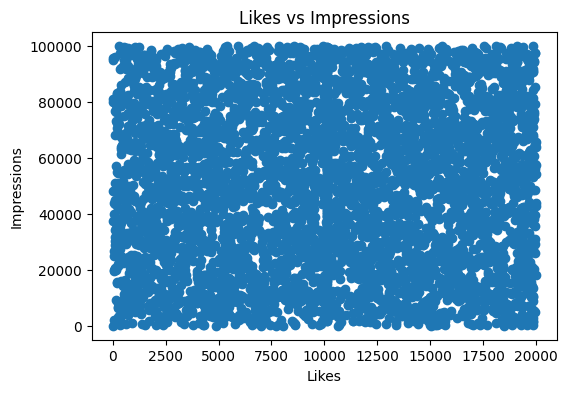

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['likes'], df['impression_count'])
plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.title("Likes vs Impressions")
plt.show()

**Line: daily engagement trend**


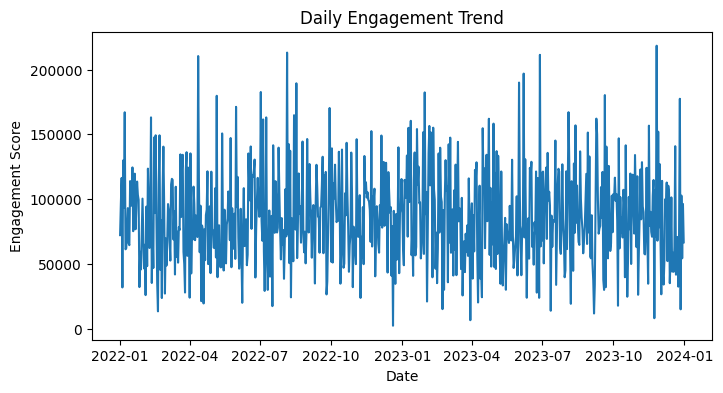

In [ ]:
daily_engagement = df.groupby('posted_at')['engagement_score'].sum()
plt.figure(figsize=(8,4))
plt.plot(daily_engagement)
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagement Score")
plt.show()

**Bar: posts by category**

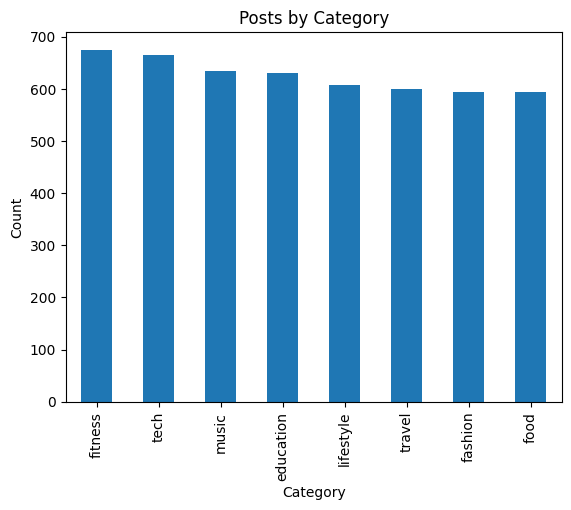

In [ ]:
df['post_category'].value_counts().plot(kind='bar')
plt.title("Posts by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**Pie: gender distribution**


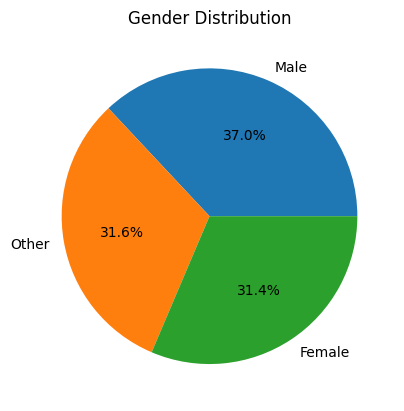

In [ ]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

**Histogram: age**

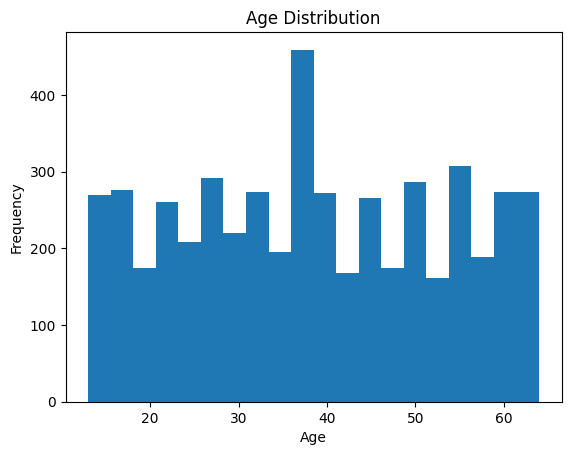

In [ ]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Box: engagement rate**


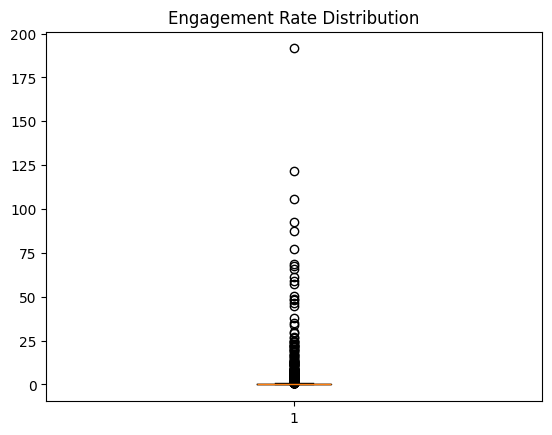

In [ ]:
plt.boxplot(df['engagement_rate'])
plt.title("Engagement Rate Distribution")
plt.show()

**Seaborn
Count plot: post type**


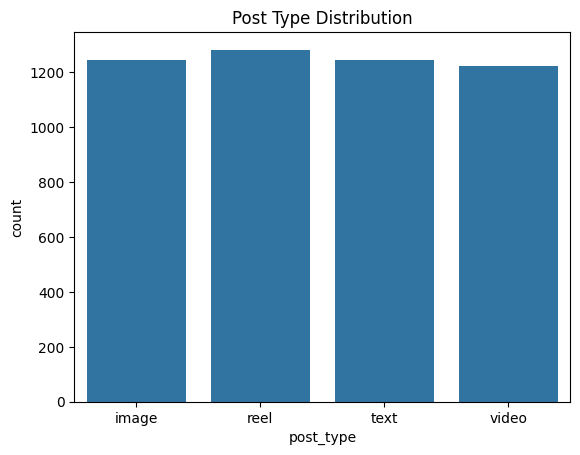

In [ ]:
sns.countplot(x='post_type', data=df)
plt.title("Post Type Distribution")
plt.show()

**Bar plot: avg likes by category**


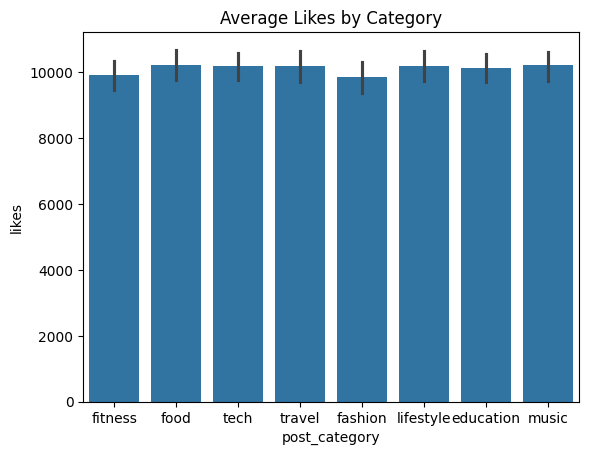

In [ ]:
sns.barplot(x='post_category', y='likes', data=df)
plt.title("Average Likes by Category")
plt.show()

**Violin: followers vs sentiment**

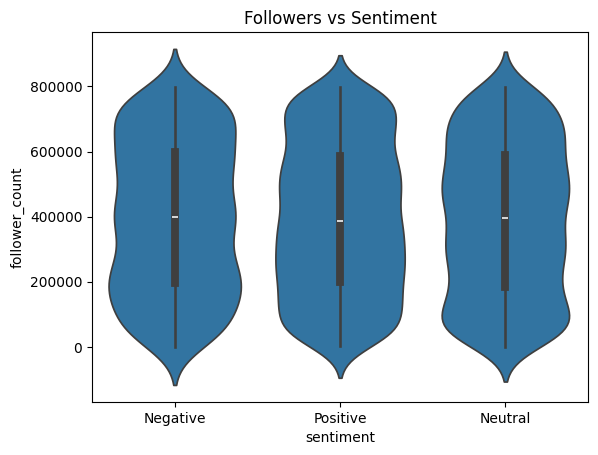

In [ ]:
sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.title("Followers vs Sentiment")
plt.show()

**Pair plot: numeric features**


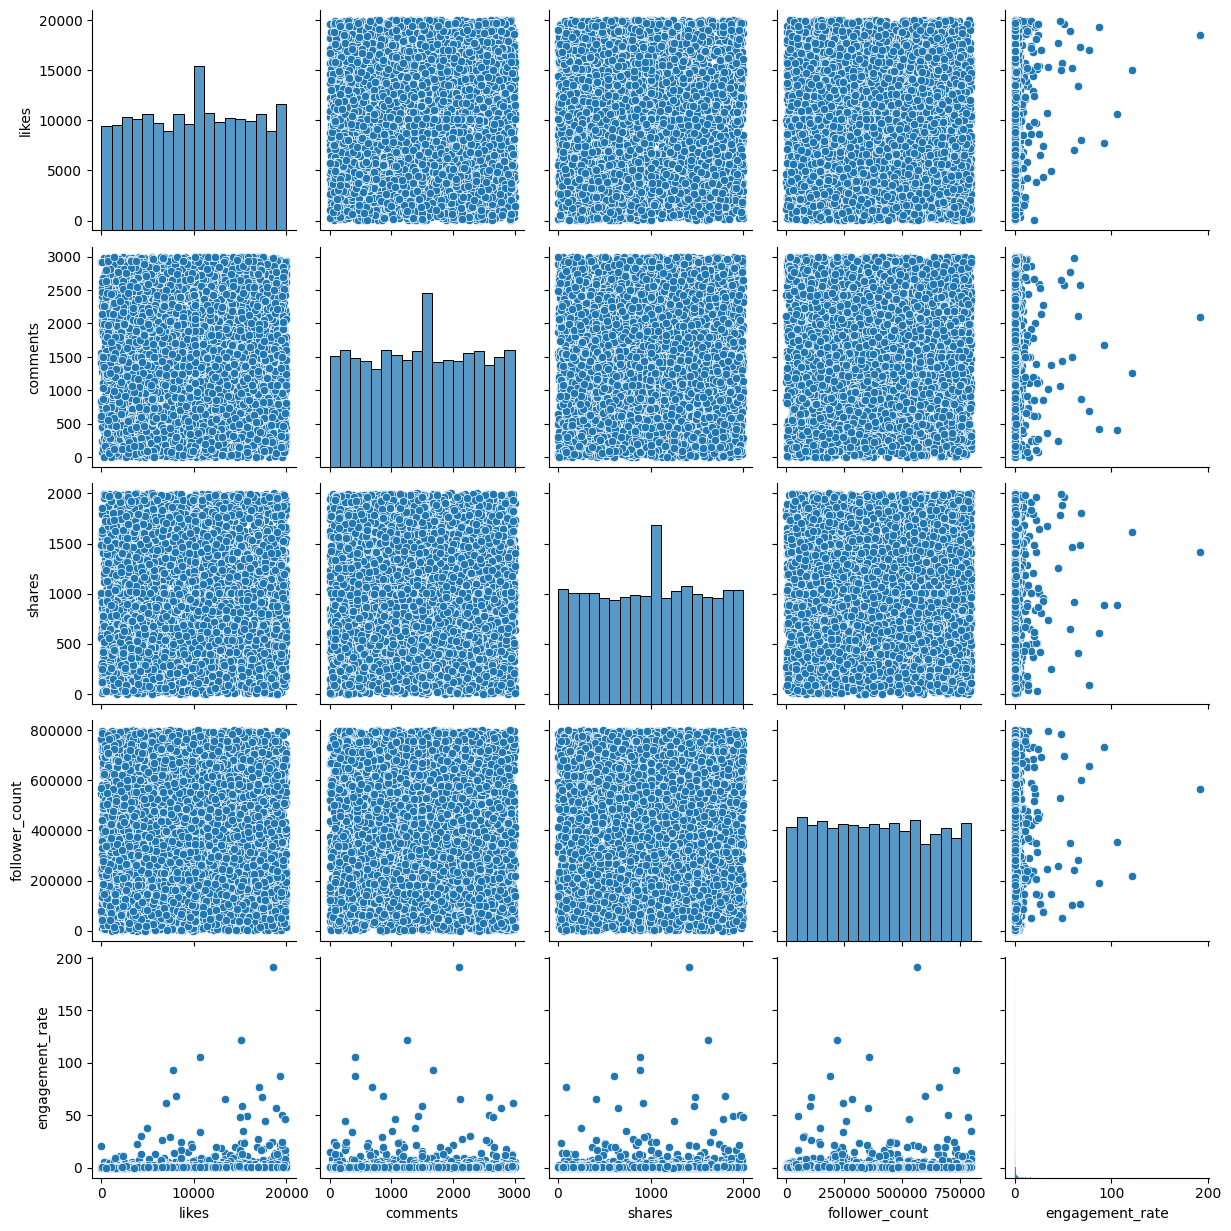

In [ ]:
numeric_cols = ['likes','comments','shares','follower_count','engagement_rate']
sns.pairplot(df[numeric_cols])
plt.show()

**Heatmap: correlation matrix**


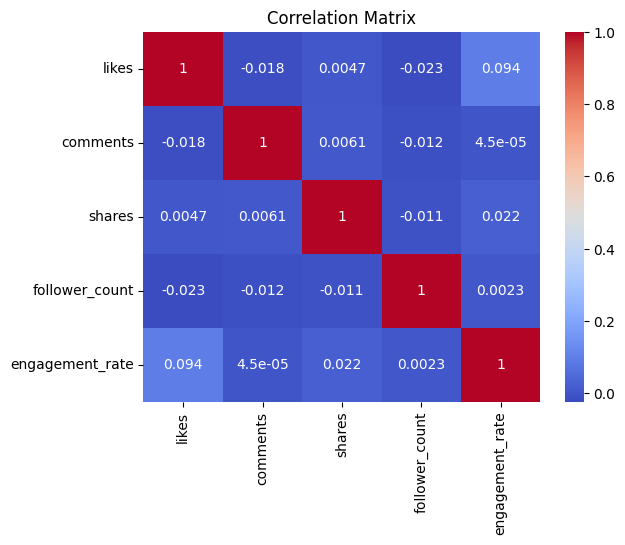

In [ ]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Interactive line chart/bar chart**



In [ ]:
fig = px.line(df, x='posted_at', y='engagement_score',title="Interactive Engagement Trend")
fig.show()

In [ ]:
fig = px.bar(df, x='post_category', y='likes',title="Likes by Category")
fig.show()

Which post types have the highest engagement?


In [48]:
df.groupby('post_type')['engagement_score'].mean().sort_values(ascending=False)

,engagement_score
post_type,
video,12664.594286
image,12649.390537
text,12613.243775
reel,12524.031567


Best-performing content category?


In [ ]:
df.groupby('post_category')['engagement_score'].mean().sort_values(ascending=False)

,engagement_score
post_category,
music,12788.399592
food,12739.208397
tech,12686.403443
travel,12650.402975
lifestyle,12639.467284
education,12578.260233
fitness,12457.681014
fashion,12356.374413


Which countries have the highest average engagement rate?


In [ ]:
df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


How age affects engagement


In [ ]:
df['Age_Group'] = pd.cut(df['age'],
bins=[15,25,35,45,60],
labels=['16-25','26-35','36-45','46-60'])
df.groupby('Age_Group')['engagement_score'].mean()

/tmp/ipykernel_389/1845147844.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,engagement_score
Age_Group,
16-25,12723.967186
26-35,12768.654749
36-45,12741.461147
46-60,12318.679220


Performance difference for verified accounts


In [ ]:
df.groupby('is_verified')['engagement_score'].mean()

,engagement_score
is_verified,
False,12644.224406
True,12309.280931


Best time of day for impressions


In [ ]:
df['Hour'] = pd.to_datetime(df['posted_at']).dt.hour
df.groupby('Hour')['impression_count'].mean().sort_values(ascending=False)

,impression_count
Hour,
0,50013.7328


Device type impact on watch time


In [ ]:
df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False)

,watch_time_sec
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


Which sentiment performs best


In [ ]:
df.groupby('sentiment')['engagement_score'].mean().sort_values(ascending=False)

,engagement_score
sentiment,
Negative,12731.442828
Positive,12665.701190
Neutral,12448.102243


Behavior of negative/neutral sentiment posts


In [ ]:
df.groupby('sentiment')[['likes','comments','shares']].mean().sort_values(by=['likes','comments','shares'],ascending=False)

,likes,comments,shares
sentiment,,,
Negative,10208.145116,1516.224683,1007.073029
Positive,10180.108763,1480.826356,1004.766071
Neutral,9923.238981,1528.543564,996.319698
